In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.svm import SVC 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

Loding the data

In [2]:
df = pd.read_csv("../data/UCI_Credit_Card.csv")

df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


Renaming the last col to shorter name

In [3]:
df.rename({'default.payment.next.month':'DEFAULT'}, axis='columns', inplace=True)

Droping the ID column

In [4]:
df.drop('ID', axis=1, inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


checking data types

In [5]:
df.dtypes

LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [6]:
df['SEX'].unique()

array([2, 1])

In [7]:
df['EDUCATION'].unique()  

array([2, 1, 3, 5, 4, 6, 0])

In [8]:
df['MARRIAGE'].unique()  

array([1, 2, 3, 0])

In [9]:
len(df.loc[(df['EDUCATION'] == 0)|(df['MARRIAGE'] == 0)])

68

In [10]:
len(df)

30000

using SimpleImputer to filled missing values

In [11]:
imputer = SimpleImputer(missing_values=0, strategy='most_frequent')
cols_to_fill = ['EDUCATION', 'MARRIAGE']
df[cols_to_fill] = imputer.fit_transform(df[cols_to_fill])

In [12]:
df['MARRIAGE'].unique()  

array([1, 2, 3])

In [13]:
df['EDUCATION'].unique()  

array([2, 1, 3, 5, 4, 6])

Downsample the data first we split it into default and non default

In [14]:
df_no_default = df[df['DEFAULT'] == 0]
df_default = df[df['DEFAULT'] == 1]


Now we downsample the dataset

In [15]:
df_no_default_downsample = resample(df_no_default, replace=False, n_samples=1000, random_state=42)
len(df_no_default_downsample)

1000

In [16]:
df_default_downsample = resample(df_default, replace=False, n_samples=1000, random_state=42)
len(df_no_default_downsample)

1000

Now lets merge the two dataset

In [17]:
df_downsample = pd.concat([df_default_downsample, df_no_default_downsample])
len(df_downsample)

2000

In [18]:
X = df_downsample.drop('DEFAULT', axis=1).copy()
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
6820,220000.0,2,2,1,32,-2,-2,-2,-2,-2,...,175771.0,180794.0,184650.0,167856.0,6243.0,6376.0,7942.0,8270.0,170000.0,6002.0
19685,50000.0,2,1,1,38,0,0,0,2,0,...,14568.0,14008.0,14827.0,19297.0,1000.0,3560.0,0.0,1000.0,4656.0,712.0
20251,90000.0,2,3,1,54,-2,-2,-2,-2,-2,...,0.0,0.0,1805.0,0.0,0.0,0.0,0.0,1805.0,0.0,0.0
6944,160000.0,2,2,1,50,-1,-1,-1,-1,-1,...,1390.0,390.0,390.0,0.0,2261.0,1390.0,390.0,390.0,0.0,780.0
20518,40000.0,1,1,2,27,2,0,0,0,0,...,11471.0,11776.0,12660.0,12660.0,2500.0,2000.0,1500.0,2330.0,2300.0,1000.0


In [19]:
y = df_downsample['DEFAULT'].copy()
y.head()

6820     1
19685    1
20251    1
6944     1
20518    1
Name: DEFAULT, dtype: int64

In [20]:
pd.get_dummies(X, columns=['MARRIAGE']).head()

,LIMIT_BAL,SEX,EDUCATION,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
6820,220000.0,2,2,32,-2,-2,-2,-2,-2,-1,...,167856.0,6243.0,6376.0,7942.0,8270.0,170000.0,6002.0,True,False,False
19685,50000.0,2,1,38,0,0,0,2,0,0,...,19297.0,1000.0,3560.0,0.0,1000.0,4656.0,712.0,True,False,False
20251,90000.0,2,3,54,-2,-2,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,1805.0,0.0,0.0,True,False,False
6944,160000.0,2,2,50,-1,-1,-1,-1,-1,-1,...,0.0,2261.0,1390.0,390.0,390.0,0.0,780.0,True,False,False
20518,40000.0,1,1,27,2,0,0,0,0,0,...,12660.0,2500.0,2000.0,1500.0,2330.0,2300.0,1000.0,False,True,False


In [21]:
X_encoded = pd.get_dummies(X, columns=['SEX', 'EDUCATION','MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'])
X_encoded.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,...,PAY_5_5,PAY_5_7,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_6,PAY_6_7
6820,220000.0,32,183718.0,172250.0,175771.0,180794.0,184650.0,167856.0,6243.0,6376.0,...,False,False,False,True,False,False,False,False,False,False
19685,50000.0,38,10379.0,11200.0,14568.0,14008.0,14827.0,19297.0,1000.0,3560.0,...,False,False,False,False,True,False,False,False,False,False
20251,90000.0,54,0.0,0.0,0.0,0.0,1805.0,0.0,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False
6944,160000.0,50,1261.0,2261.0,1390.0,390.0,390.0,0.0,2261.0,1390.0,...,False,False,False,True,False,False,False,False,False,False
20518,40000.0,27,10181.0,11058.0,11471.0,11776.0,12660.0,12660.0,2500.0,2000.0,...,False,False,False,False,True,False,False,False,False,False


Split the data into train and test

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y , random_state=42)
X_train_scaled = scale(X_train)
X_test_scaled = scale(X_test)

Making the SVM

In [23]:
clf_svm = SVC(random_state=42)
clf_svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Now lets see the performance of the SVM 

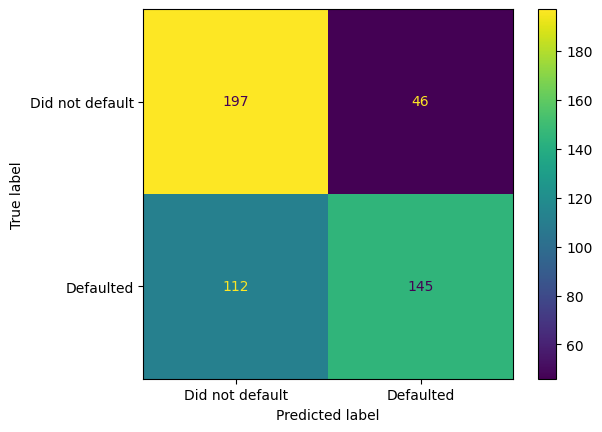

In [24]:
ConfusionMatrixDisplay.from_estimator(clf_svm, X_test_scaled, y_test, display_labels=["Did not default", "Defaulted"])

Lets try to optimize it using GridSearchCV()

In [25]:
param_grid = [{'C':[0.5, 1, 10, 100],'gamma': ['scale', 1, 0.1 , 0.01, 0.001, 0.0001], 'kernel':['rbf']}]

optimal_params = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', verbose=0 )

In [26]:
optimal_params.fit(X_train_scaled,y_train)
print(optimal_params.best_params_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [27]:
clf_svm = SVC(random_state=42, C=10, gamma=0.01)
clf_svm.fit(X_train_scaled,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


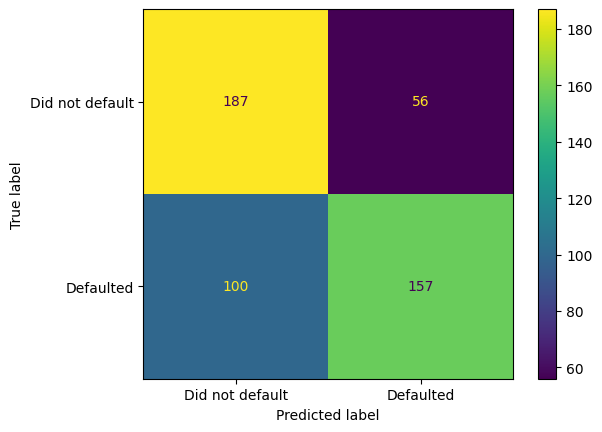

In [28]:
ConfusionMatrixDisplay.from_estimator(clf_svm, X_test_scaled, y_test, display_labels=["Did not default", "Defaulted"])

In [29]:
len(df_downsample.columns)

24

Lets implement PCA for visualization

<function matplotlib.pyplot.show(close=None, block=None)>

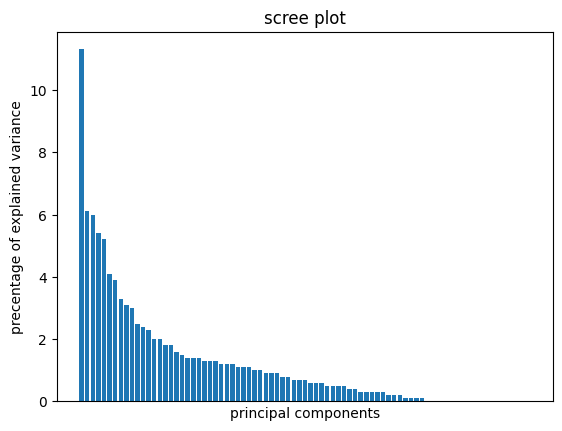

In [30]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

per_var = np.round(pca.explained_variance_ratio_*100, decimals=1)
labels = [str(x) for x in range(1,len(per_var)+1)]

plt.bar(x=range(1,len(per_var)+1), height=per_var)
plt.tick_params(axis='x', which='both',bottom=False, top=False, labelbottom=False)
plt.ylabel('precentage of explained variance')
plt.xlabel('principal components')
plt.title('scree plot')
plt.show